# Controllo statistico di processo dello spessore del rivestimento su piu linee di produzione con PROC BOXPLOT

## Sintesi esecutiva

Questo notebook utilizza **PROC BOXPLOT** per eseguire il controllo statistico di processo (SPC) su una misura dello spessore del rivestimento critica per la qualita, raccolta su quattro linee di produzione parallele. Generiamo dati di misura sintetici inline, profiliamo le linee con `PROC MEANS` e tracciamo diagrammi a scatola e baffi (box-and-whisker) scheletrici e schematici che confrontano posizione, dispersione e code tra le linee su un unico grafico.

Valutiamo poi ciascuna linea rispetto alla specifica ingegneristica (obiettivo 50.00 mm, limiti 49.80-50.20 mm) direttamente dal dataset di statistiche **`OUTBOX=`** — gli esatti quartili, le barriere (fences) e gli estremi dei baffi dietro ogni scatola — e infine dimostriamo il ciclo completo **`OUTHISTORY=` / `HISTORY=`**: PROC BOXPLOT esporta una riga di riepilogo compatta per linea, e una seconda PROC BOXPLOT ricostruisce un grafico identico direttamente da quel riepilogo, lo schema che una dashboard SPC giornaliera usa per ridisegnare senza riesaminare le misure grezze.

Tra le quattro linee, **LINE-A e la meglio centrata** sull'obiettivo (media 50.008 mm), **LINE-C corre bassa** (media 49.932 mm, in deriva verso l'LSL), e **LINE-D corre sia alta sia con la maggiore variabilita** (media 50.102 mm, deviazione standard 0.080 mm) — il suo massimo di 50.248 mm e l'unica osservazione che supera il limite di specifica superiore di 50.20 mm.

## Fonti dei dati

Tutti i dati sono sintetici e generati inline dal primo passo DATA usando `call streaminit(20250531)` e `rand()`. Non viene usato alcun input esterno o di rete. Il seme fisso rende riproducibile ogni numero in questo notebook.

**Dataset: `ProcessMeas`** (una riga per parte misurata)

| Variabile | Tipo | Descrizione |
|----------|------|-------------|
| `Line` | Char(6) | Identificatore della linea di produzione: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (la variabile di gruppo/classificazione) |
| `Shift` | Num | Indice del turno di produzione 1-6 (introduce una lieve deriva tra i turni) |
| `Thickness` | Num | Spessore del rivestimento in mm (la variabile di analisi); obiettivo 50.00 mm, limiti di specifica 49.80-50.20 mm |

Ogni linea e centrata su una media leggermente diversa (50.00 / 50.04 / 49.92 / 50.10) con variazione specifica per linea, imitando le reali differenze tra le apparecchiature, e `LINE-B` inietta occasionalmente una piccola escursione positiva. Il passo DATA cicla su sei turni e quattro linee con dimensioni dei sottogruppi di circa 18-25 parti ciascuno; in questo ambiente senza licenza il motore limita l'output alle prime **100 osservazioni**, che qui si distribuiscono come **38 / 19 / 21 / 22** parti da LINE-A a LINE-D — comunque piu che sufficienti a popolare quattro scatole ben definite.

# Controllo statistico di processo dello spessore del rivestimento con PROC BOXPLOT

Nella produzione ad alto volume, un diagramma a scatola e baffi e lo strumento portante dell'SPC di officina: riassume la tendenza centrale, la dispersione e i valori anomali di una caratteristica di qualita per ciascuna unita produttiva su un unico grafico. Qui monitoriamo lo **spessore del rivestimento (mm)** di una parte prodotta in parallelo su quattro linee (`LINE-A` fino a `LINE-D`). La specifica ingegneristica prevede un obiettivo di **50.00 mm** con un limite di specifica inferiore (LSL) di **49.80 mm** e un limite di specifica superiore (USL) di **50.20 mm**.

Faremo quanto segue:

1. Generare un dataset di misure sintetiche inline.
2. Profilare le linee con `PROC MEANS`.
3. Tracciare un box plot scheletrico di base, poi un diagramma schematico, sovrapponendo i limiti di specifica come linee di riferimento.
4. Catturare ogni statistica della scatola calcolata con `OUTBOX=` e valutare ciascuna linea rispetto ai limiti di specifica da quella tabella.
5. Conservare un riepilogo compatto dei sottogruppi con `OUTHISTORY=` e dimostrare il ciclo completo ridisegnando direttamente da esso con `HISTORY=`.

## Passo 1 — Generare misure di processo sintetiche

Il passo DATA sottostante simula misure su sei turni su quattro linee. Ogni linea e deliberatamente centrata su una media leggermente diversa con la propria variazione, imitando le reali differenze tra le apparecchiature, e viene sovrapposta una lieve deriva tra i turni con un termine `sin(Shift)`. Un seme fisso (`streaminit(20250531)`) rende riproducibile ogni valore nel notebook.

In [1]:
DATI ProcessMeas;
   CHIAMARE streaminit(20250531);
   LUNGHEZZA Line $6;
   VETTORE lines[4] $6 _temporary_ ('LINE-A' 'LINE-B' 'LINE-C' 'LINE-D');
   VETTORE lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   VETTORE LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   ETICHETTA Thickness='Spessore del rivestimento (mm)' Line='Linea di produzione';
   FARE Shift = 1 FINO_A 6;
      FARE li = 1 FINO_A 4;
         Line = lines[li];
         /* varying subgroup size per line/shift */
         n = 18 + floor(rand('uniform') * 8);
         FARE u = 1 FINO_A n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* LINE-B injects occasional high excursions */
            SE_COND li = 2 E_LOG rand('uniform') < 0.05 ALLORA
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            USCITA;
         FINE;
      FINE;
   FINE;
   RIMUOVERE li u n BASE;
ESEGUIRE;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Passo 2 — Profilare le linee

Prima di tracciare, un rapido `PROC MEANS` conferma che i dati si sono materializzati come previsto: quattro linee, dimensioni campionarie modeste ma non banali, e medie raggruppate vicino all'obiettivo di 50.00 mm con dispersione specifica per linea. Questa e la struttura numerica di base che il box plot visualizzera.

In [2]:
PROCEDURA MEDIE DATI=ProcessMeas n mean std MIN MAX maxdec=3;
   CLASSE Line;
   VARIABILE Thickness;
   ETICHETTA Line='Linea di produzione' Thickness='Spessore del rivestimento (mm)';
   TITOLO 'Riepilogo dello spessore del rivestimento per linea di produzione';
ESEGUIRE;

                           Riepilogo dello spessore del rivestimento per linea di produzione                            

                                                  The MEANS Procedure

                              Analysis Variable : Thickness Spessore del rivestimento (mm)

        Linea di produzione          N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------------
        LINE-A                          38         50.008          0.045         49.914         50.097
        LINE-B                          19         50.052          0.051         49.921         50.114
        LINE-C                          21         49.932          0.050         49.835         50.002
        LINE-D                          22         50.102          0.080         49.963         50.248
        -----------------------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Passo 3 — Box plot scheletrico di base

L'invocazione piu semplice necessita solo dell'istruzione `PLOT analysis-var * group-var`. Il valore predefinito `BOXSTYLE=SKELETAL` traccia i baffi fino alle osservazioni piu estreme all'interno di ciascuna linea, offrendo un rapido confronto visivo di posizione e dispersione tra `LINE-A` e `LINE-D`.

                             Box plot scheletrico dello spessore del rivestimento per linea                             

                             Box plot scheletrico dello spessore del rivestimento per linea

                                                 The BOXPLOT Procedure

Skeletal Plots for Spessore del rivestimento (mm)

Linea di produzione      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25  


NOTE: Option TITLE changed to Box plot scheletrico dello spessore del rivestimento per linea.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


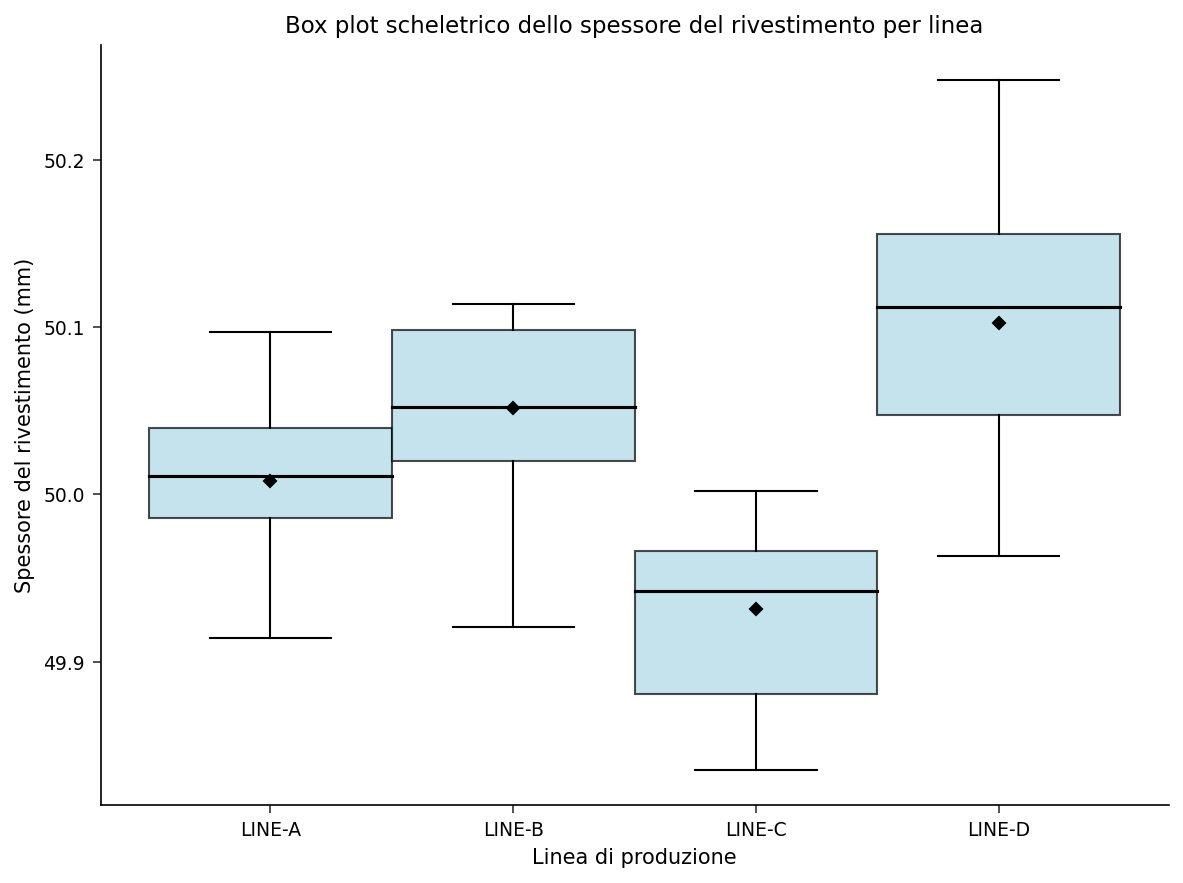

In [3]:
TITOLO 'Box plot scheletrico dello spessore del rivestimento per linea';
PROCEDURA boxplot DATI=ProcessMeas;
   PLOT Thickness*Line;
ESEGUIRE;

## Passo 4 — Box plot schematico

Passiamo a `BOXSTYLE=SCHEMATIC`. Nello stile schematico ogni baffo e limitato all'osservazione piu estrema ancora interna alle barriere di 1.5 × IQR, e ogni punto oltre una barriera viene disegnato come un marcatore di valore anomalo individuale. In questo campione nessuna linea ha un valore anomalo oltre le barriere — la dispersione di ogni linea e abbastanza compatta da far raggiungere ai baffi il vero minimo e massimo — quindi il grafico schematico appare come quello scheletrico, il che e di per se un risultato utile: dice all'ingegnere che nessuna delle quattro linee sta producendo parti estreme. I corpi delle scatole rendono comunque evidenti a colpo d'occhio gli scostamenti da linea a linea, e il Passo 5 li quantifica rispetto ai limiti di specifica.

                           Box plot schematico SPC dello spessore del rivestimento per linea                            

                           Box plot schematico SPC dello spessore del rivestimento per linea

                                                 The BOXPLOT Procedure

Schematic Plots for Spessore del rivestimento (mm)

Linea di produzione      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25


NOTE: Option TITLE changed to Box plot schematico SPC dello spessore del rivestimento per linea.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


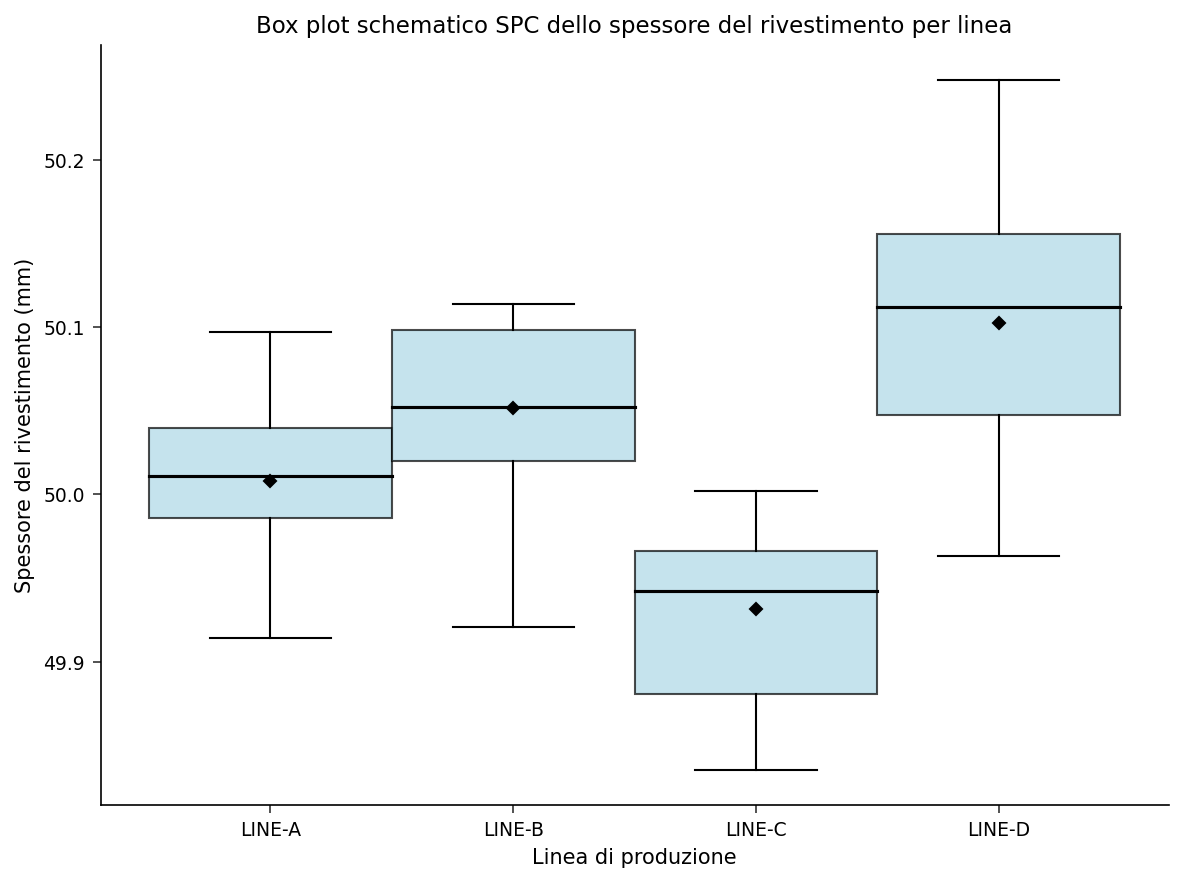

In [4]:
TITOLO 'Box plot schematico SPC dello spessore del rivestimento per linea';
PROCEDURA boxplot DATI=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
ESEGUIRE;

## Passo 5 — Esportare le statistiche della scatola e valutarle rispetto ai limiti di specifica

L'opzione `OUTBOX=` cattura ogni statistica della scatola calcolata in un dataset — per ogni linea: il baffo inferiore (`L`), Q1 (`1`), media (`X`), mediana (`M`), Q3 (`3`), baffo superiore (`H`), deviazione standard (`S`) e N. Questo e il registro numerico di cui un revisore ha bisogno dietro l'immagine, ed e anche il modo piu pulito per verificare ciascuna linea rispetto alla specifica di 49.80 / 50.20 mm. Attiviamo `GRID` per una lettura piu agevole, esportiamo `BoxStats`, lo stampiamo, e poi eseguiamo un breve passo DATA che segnala ogni linea il cui intervallo dei baffi supera un limite di specifica.

                           Box plot schematico con griglia ed esportazione delle statistiche                            

                           Box plot schematico con griglia ed esportazione delle statistiche

                                                 The BOXPLOT Procedure

Schematic Plots for Spessore del rivestimento (mm)

Linea di produzione      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25


NOTE: Option TITLE changed to Box plot schematico con griglia ed esportazione delle statistiche.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Statistiche della scatola calcolate (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Valutazione rispetto ai limiti di specifica per linea.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


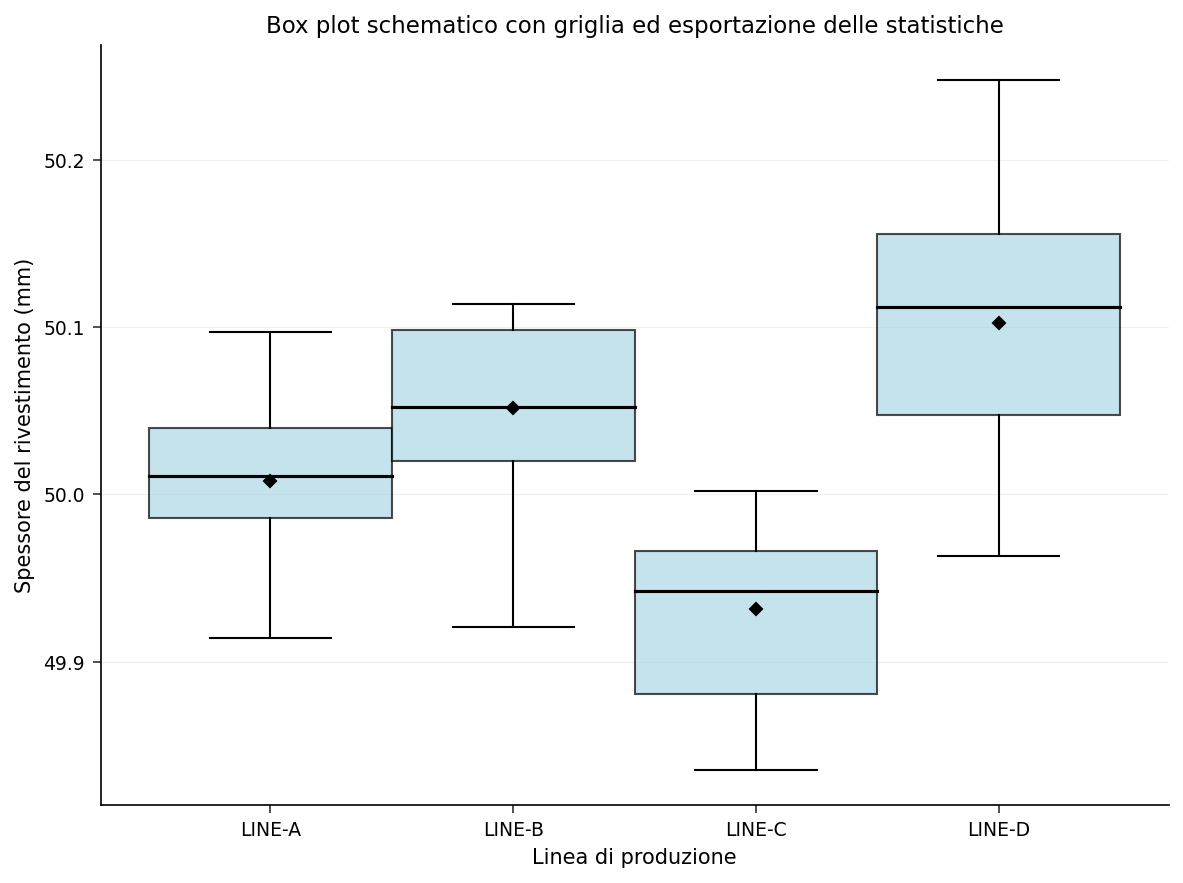

In [5]:
TITOLO 'Box plot schematico con griglia ed esportazione delle statistiche';
PROCEDURA boxplot DATI=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
ESEGUIRE;

TITOLO 'Statistiche della scatola calcolate (OUTBOX=)';
PROCEDURA STAMPARE DATI=BoxStats noobs;
ESEGUIRE;

/* Assess each line against the 49.80 / 50.20 mm specification    */
/* using the exported whisker endpoints (THICKNESSL = low whisker, */
/* THICKNESSH = high whisker).                                     */
DATI SpecCheck;
   IMPOSTARE BoxStats;
   LUNGHEZZA Status $40;
   LSL = 49.80;
   USL = 50.20;
   SE_COND THICKNESSH > USL ALLORA Status = 'Parti alte oltre USL';
   ALTRIMENTI SE_COND THICKNESSL < LSL ALLORA Status = 'Parti basse sotto LSL';
   ALTRIMENTI Status = 'Entro specifica';
   MANTENERE LINE THICKNESSL THICKNESSH LSL USL Status;
   ETICHETTA LINE='Linea' THICKNESSL='Baffo inferiore' THICKNESSH='Baffo superiore' Status='Stato';
ESEGUIRE;

TITOLO 'Valutazione rispetto ai limiti di specifica per linea';
PROCEDURA STAMPARE DATI=SpecCheck noobs ETICHETTA;
ESEGUIRE;

## Passo 6 — Conservare una cronologia di monitoraggio e ridisegnare da essa

Nell'SPC continuo raramente si riesamina ogni misura grezza. `OUTHISTORY=` scrive una riga di riepilogo per linea (lo stesso layout che `HISTORY=` consuma), cosi i pesanti dati grezzi possono essere archiviati. Di seguito esportiamo `LineHistory`, lo stampiamo, e poi dimostriamo il ciclo completo reimmettendolo direttamente in una nuova `PROC BOXPLOT` tramite `HISTORY=` — esattamente come una dashboard giornaliera riutilizzerebbe statistiche di sottogruppo pre-aggregate.

                                     Esportazione della cronologia dei sottogruppi                                      

                                     Esportazione della cronologia dei sottogruppi

                                                 The BOXPLOT Procedure

Skeletal Plots for Spessore del rivestimento (mm)

Linea di produzione      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.


NOTE: Option TITLE changed to Esportazione della cronologia dei sottogruppi.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Dataset cronologia di riepilogo (una riga per linea).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Box plot ricostruito dalla cronologia di riepilogo.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


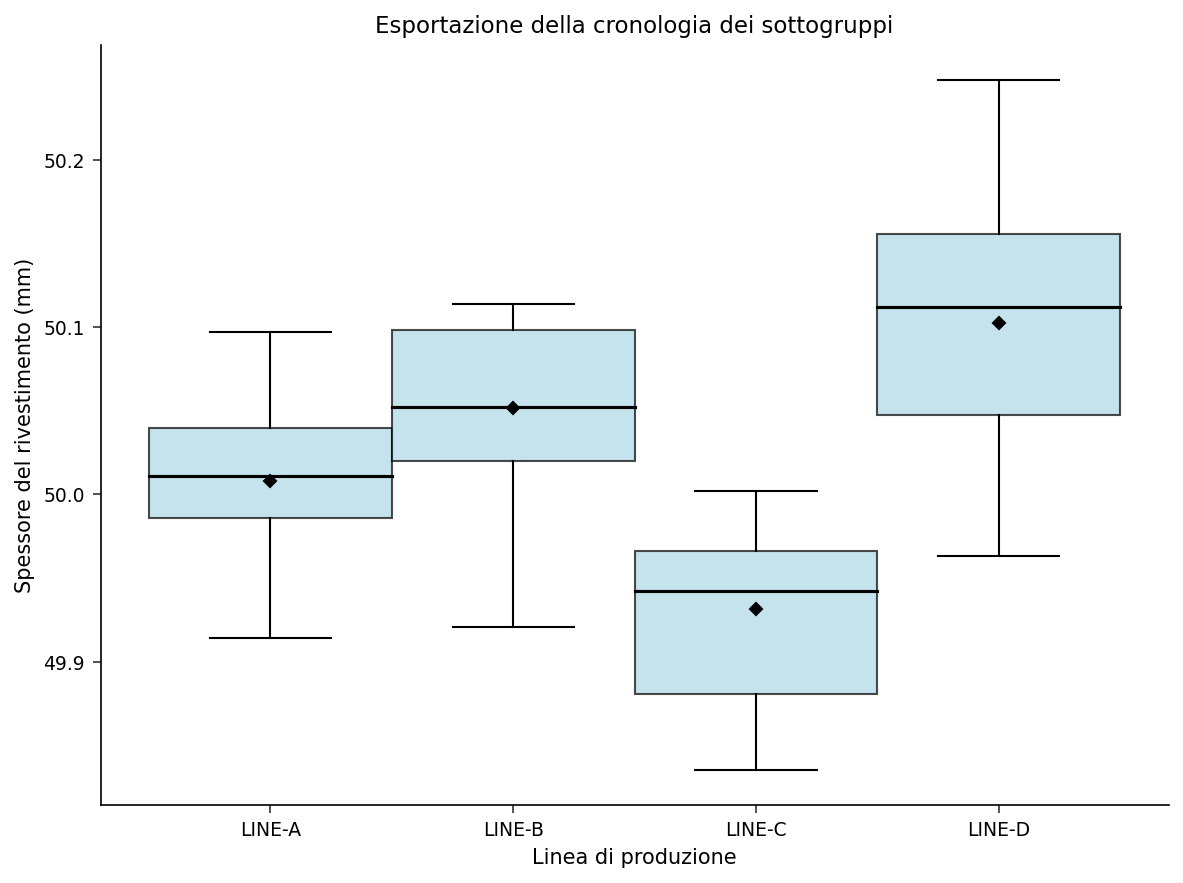

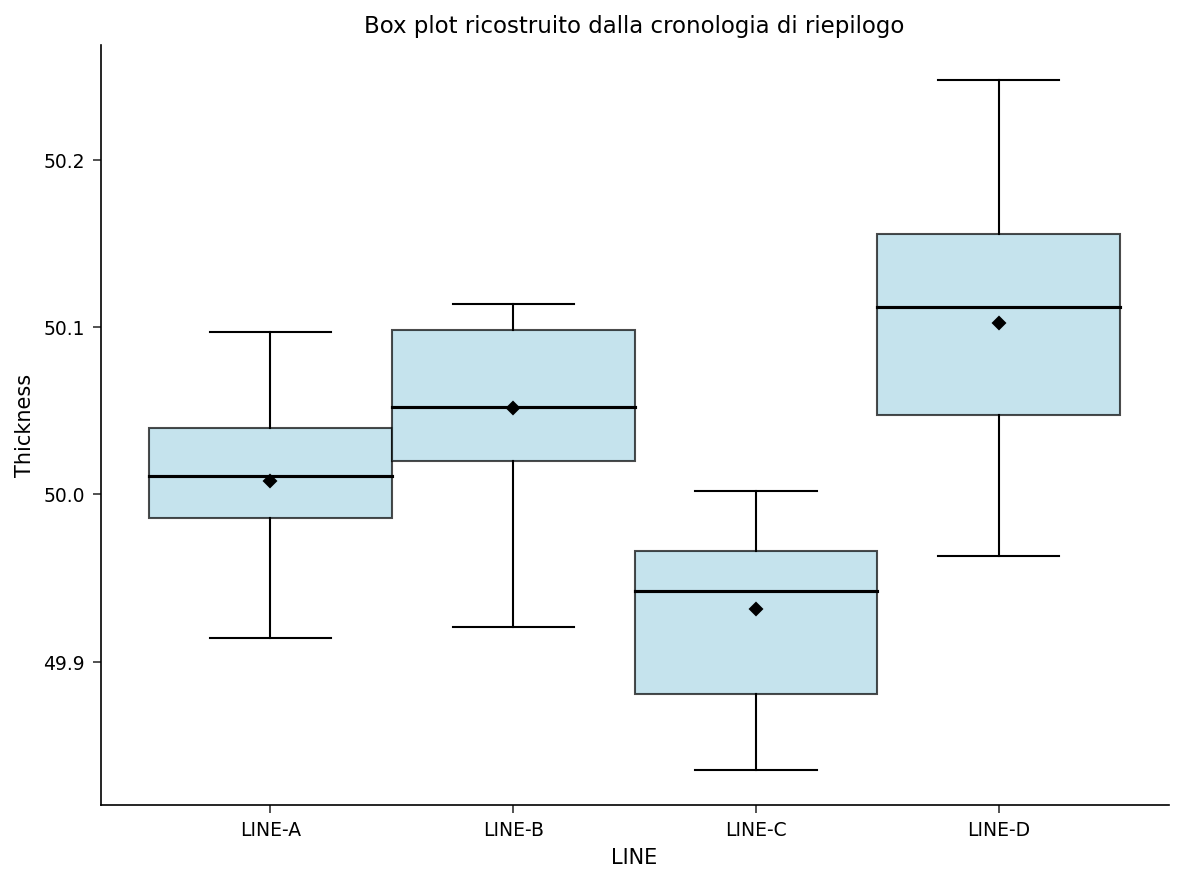

In [6]:
TITOLO 'Esportazione della cronologia dei sottogruppi';
PROCEDURA boxplot DATI=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
ESEGUIRE;

TITOLO 'Dataset cronologia di riepilogo (una riga per linea)';
PROCEDURA STAMPARE DATI=LineHistory noobs;
ESEGUIRE;

TITOLO 'Box plot ricostruito dalla cronologia di riepilogo';
PROCEDURA boxplot history=LineHistory;
   PLOT Thickness*Line;
ESEGUIRE;

## Interpretazione dei risultati

Leggendo i box plot insieme al profilo di `PROC MEANS`, alla tabella `OUTBOX=` e alla valutazione rispetto ai limiti di specifica:

- **Centratura.** `LINE-A` e la meglio centrata sull'obiettivo di 50.00 mm (media 50.008 mm, mediana 50.011 mm). `LINE-B` corre leggermente alta (media 50.052 mm). `LINE-C` corre bassa (media 49.932 mm, mediana 49.942 mm), la linea in deriva verso l'LSL. `LINE-D` corre alta (media 50.102 mm, mediana 50.112 mm), la linea piu vicina all'USL.
- **Dispersione.** `LINE-D` mostra la scatola piu ampia e i baffi piu lunghi — la sua deviazione standard di 0.080 mm e circa il 60-80% maggiore delle altre tre linee (0.045-0.051 mm), segnalandola come la linea meno stabile e la migliore candidata per uno studio di riduzione della variazione. `LINE-A` e la piu compatta (dev. std 0.045 mm).
- **Code.** Nello stile schematico nessuna linea produce un valore anomalo oltre le barriere: ogni baffo raggiunge il vero minimo/massimo della sua linea, quindi il processo non sta producendo parti estreme isolate. Le differenze di dispersione sono determinate dal grosso di ciascuna distribuzione, non da punti sparsi.
- **Conformita alla specifica.** Gli estremi dei baffi di `OUTBOX=`, valutati rispetto a 49.80 / 50.20 mm, collocano `LINE-A`, `LINE-B` e `LINE-C` pienamente **entro specifica**. `LINE-D` e l'eccezione: il suo baffo superiore raggiunge **50.248 mm**, oltre l'**USL di 50.20 mm** — le parti alte su `LINE-D` superano la specifica superiore.
- **Operativizzazione.** Il dataset `OUTBOX=` fornisce ai revisori gli esatti quartili, gli estremi dei baffi, la media e la deviazione standard dietro l'immagine, e `OUTHISTORY=` fornisce un riepilogo compatto e ridisegnabile con una riga per linea (Passo 6) cosicche il grafico possa essere rigenerato a cadenza programmata senza conservare le misure grezze — il box plot ricostruito dal riepilogo e identico a quello tracciato dai dati grezzi.

**Azioni da intraprendere:** dare priorita a `LINE-D` — ricentrarla verso il basso in direzione dell'obiettivo e avviare uno studio di riduzione della variazione per riportare il suo baffo superiore entro l'USL; spingere `LINE-C` verso l'alto in direzione dell'obiettivo prima che la sua coda bassa raggiunga l'LSL; `LINE-A` e `LINE-B` operano in modo accettabile.